
- **Reference Paper**: "Clustering is back: Reaching state-of-the-art LiDAR instance segmentation without training" (Sautier et al., 2025)
- **Dataset**: http://www.poss.pku.edu.cn/semanticposs.html

This file focus on using one dataset


Contents
1. **ALPINE Implementation**: A class-based implementation of the ALPINE clustering logic using bounding-box heuristics.
2. **Baselines**: Implementation of standard DBSCAN and MiniBatchKMeans clustering methods for comparison.
3. **Cross-Dataset Evaluation**: The model is evaluated on the **SemanticPOSS** dataset using Panoptic Quality (PQ), Segmentation Quality (SQ), and Recognition Quality (RQ) metrics.
4. **Visualization**: Comparative plots and point cloud visualizations of the results.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from nuscenes.nuscenes import NuScenes
from sklearn.cluster import DBSCAN, MiniBatchKMeans



In [13]:
class Alpine:
    def __init__(self, thing_classes, bbox_web, split=True):
        self.thing_classes = thing_classes
        self.bbox_web = bbox_web
        self.split = split

    def fit_predict(self, pc, sem_labels):
        inst = np.zeros(len(sem_labels), dtype=int)
        offset = 1
        for cls in self.thing_classes:
            mask = sem_labels == cls
            if mask.sum() < 10: continue
            points = pc[mask]
            # Use DBSCAN with eps based on bbox/home/yadanar/Downloads/Dataset/v1.0-mini'
            eps = self.bbox_web[cls][0] / 5.0  # Arbitrary scaling
            min_samples = 10
            db = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
            labels = db.labels_
            valid = labels != -1
            inst[mask] = np.where(valid, labels + offset, 0)
            offset += np.max(labels) + 2 if np.any(valid) else 0
        return inst

In [14]:
# Traditional Baselines
def run_dbscan(pc, sem_labels):
    inst = np.zeros_like(sem_labels, dtype=int)
    offset = 1
    for cls in THING_CLASSES:
        mask = sem_labels == cls
        if mask.sum() < 10: continue
        db = DBSCAN(eps=0.5, min_samples=10).fit(pc[mask, :2])
        labels = db.labels_
        valid = labels != -1
        inst[mask] = np.where(valid, labels + offset, 0)
        offset += np.max(labels) + 2 if np.any(valid) else 0
    return inst

def run_minibatch_kmeans(pc, sem_labels):
    inst = np.zeros_like(sem_labels, dtype=int)
    offset = 1
    for cls in THING_CLASSES:
        mask = sem_labels == cls
        if mask.sum() < 15: continue
        # Estimate number of clusters based on point density
        n_points = mask.sum()
        n_clusters = max(1, min(20, n_points // 50))  # Adaptive cluster count
        clusterer = MiniBatchKMeans(
            n_clusters=n_clusters,
            batch_size=100,
            random_state=42,
            max_iter=100
        ).fit(pc[mask, :2])
        labels = clusterer.labels_
        inst[mask] = labels + offset
        offset += n_clusters
    return inst

# ALPINE Implementation
BBOX_WEB = {
    1: [2.0, 0.5], 2: [1.75, 0.61], 3: [10.0, 3.0], 4: [4.75, 1.92], 
    5: [10.0, 3.0], 6: [2.2, 0.95], 7: [0.93, 0.93], 8: [0.41, 0.41], 
    9: [12.29, 2.90], 10: [6.93, 2.51]
}

def run_alpine(pc, sem_labels, split=True):
    alpine = Alpine(THING_CLASSES, BBOX_WEB, split=split)
    return alpine.fit_predict(pc[:, :2], sem_labels)

In [15]:
class PanopticMetrics:
    def __init__(self, n_classes=17, min_points=15):
        self.n_classes = n_classes
        self.min_points = min_points
        self.reset()

    def reset(self):
        self.tp = np.zeros(self.n_classes)
        self.fp = np.zeros(self.n_classes)
        self.fn = np.zeros(self.n_classes)
        self.iou_sum = np.zeros(self.n_classes)

    def add_frame(self, pred_sem, pred_inst, gt_sem, gt_inst):
        for cl in range(1, self.n_classes):
            p_mask, g_mask = (pred_sem == cl), (gt_sem == cl)
            u_p, counts_p = np.unique(pred_inst[p_mask & (pred_inst > 0)], return_counts=True)
            u_p = u_p[counts_p >= self.min_points]
            u_g, counts_g = np.unique(gt_inst[g_mask & (gt_inst > 0)], return_counts=True)
            u_g = u_g[counts_g >= self.min_points]

            if len(u_p) == 0 and len(u_g) == 0: continue
            
            matched_g, matched_p = set(), set()
            for pi in u_p:
                for gi in u_g:
                    inter = np.sum((pred_inst == pi) & (gt_inst == gi))
                    union = np.sum(((pred_inst == pi) | (gt_inst == gi)) & ((pred_sem == cl) | (gt_sem == cl)))
                    iou = inter / union if union > 0 else 0
                    if iou > 0.5:
                        self.tp[cl] += 1
                        self.iou_sum[cl] += iou
                        matched_p.add(pi); matched_g.add(gi)
            
            self.fp[cl] += len(u_p) - len(matched_p)
            self.fn[cl] += len(u_g) - len(matched_g)

    def get_summary(self):
        sq = self.iou_sum / np.maximum(self.tp, 1e-15)
        rq = self.tp / np.maximum(self.tp + 0.5*self.fp + 0.5*self.fn, 1e-15)
        pq = sq * rq
        include = [i for i in range(1, self.n_classes) if (self.tp[i] + self.fp[i] + self.fn[i]) > 0]
        return {
            'PQ': np.mean(pq[include]), 'SQ': np.mean(sq[include]), 'RQ': np.mean(rq[include]),
            'TP': np.sum(self.tp), 'FP': np.sum(self.fp), 'FN': np.sum(self.fn)
        }


In [16]:
import sys
from pathlib import Path

SEMANTICPOSS_ROOT = Path('/home/yadanar/Downloads/SemanticPOSS_dataset/dataset')
sys.path.insert(0, str(SEMANTICPOSS_ROOT))
from read_data import read_points, read_semlabels, read_inslabels

SEMANTICPOSS_SEQ = '00'
seq_root = SEMANTICPOSS_ROOT / 'sequences' / SEMANTICPOSS_SEQ

frame_paths = sorted((seq_root / 'velodyne').glob('*.bin'))
frame_ids = [p.stem for p in frame_paths]

# SemanticPOSS label mapping (no remapping needed, use labels directly)
# Thing classes in SemanticPOSS: 4,5,6,7,8,9,10,11,12,13,14,15,16,17,21,22
SEMANTICPOSS_THING_CLASSES = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 21, 22]

def load_semanticposs_frame(seq_root, frame_id):
    pc = read_points(seq_root / 'velodyne' / f'{frame_id}.bin')
    sem_labels = read_semlabels(seq_root / 'labels' / f'{frame_id}.label')
    inst_gt = read_inslabels(seq_root / 'labels' / f'{frame_id}.label')
    # Do not apply nuScenes MAPPER here - use SemanticPOSS labels directly
    return pc, sem_labels, inst_gt

# Define SemanticPOSS-specific clustering functions
def run_dbscan_sp(pc, sem_labels):
    inst = np.zeros_like(sem_labels, dtype=int)
    offset = 1
    for cls in SEMANTICPOSS_THING_CLASSES:
        mask = sem_labels == cls
        if mask.sum() < 10: continue
        db = DBSCAN(eps=0.5, min_samples=10).fit(pc[mask, :2])
        labels = db.labels_
        valid = labels != -1
        inst[mask] = np.where(valid, labels + offset, 0)
        offset += np.max(labels) + 2 if np.any(valid) else 0
    return inst

def run_minibatch_kmeans_sp(pc, sem_labels):
    inst = np.zeros_like(sem_labels, dtype=int)
    offset = 1
    for cls in SEMANTICPOSS_THING_CLASSES:
        mask = sem_labels == cls
        if mask.sum() < 15: continue
        # Estimate number of clusters based on point density
        n_points = mask.sum()
        n_clusters = max(1, min(20, n_points // 50))  # Adaptive cluster count
        clusterer = MiniBatchKMeans(
            n_clusters=n_clusters,
            batch_size=100,
            random_state=42,
            max_iter=100
        ).fit(pc[mask, :2])
        labels = clusterer.labels_
        inst[mask] = labels + offset
        offset += n_clusters
    return inst

def run_alpine_sp(pc, sem_labels, split=True):
    # Use class-agnostic ALPINE with adjusted bbox
    alpine = Alpine(SEMANTICPOSS_THING_CLASSES, {cls: [2.0, 0.5] for cls in SEMANTICPOSS_THING_CLASSES}, split=split)
    return alpine.fit_predict(pc[:, :2], sem_labels)

# Evaluation with proper metrics class for SemanticPOSS
class PanopticMetricsSP:
    def __init__(self, n_classes=23, min_points=15):
        self.n_classes = n_classes
        self.min_points = min_points
        self.reset()

    def reset(self):
        self.tp = np.zeros(self.n_classes)
        self.fp = np.zeros(self.n_classes)
        self.fn = np.zeros(self.n_classes)
        self.iou_sum = np.zeros(self.n_classes)

    def add_frame(self, pred_sem, pred_inst, gt_sem, gt_inst):
        for cl in SEMANTICPOSS_THING_CLASSES:
            p_mask, g_mask = (pred_sem == cl), (gt_sem == cl)
            u_p, counts_p = np.unique(pred_inst[p_mask & (pred_inst > 0)], return_counts=True)
            u_p = u_p[counts_p >= self.min_points]
            u_g, counts_g = np.unique(gt_inst[g_mask & (gt_inst > 0)], return_counts=True)
            u_g = u_g[counts_g >= self.min_points]

            if len(u_p) == 0 and len(u_g) == 0: continue
            
            matched_g, matched_p = set(), set()
            for pi in u_p:
                for gi in u_g:
                    inter = np.sum((pred_inst == pi) & (gt_inst == gi))
                    union = np.sum(((pred_inst == pi) | (gt_inst == gi)) & ((pred_sem == cl) | (gt_sem == cl)))
                    iou = inter / union if union > 0 else 0
                    if iou > 0.5:
                        self.tp[cl] += 1
                        self.iou_sum[cl] += iou
                        matched_p.add(pi); matched_g.add(gi)
            
            self.fp[cl] += len(u_p) - len(matched_p)
            self.fn[cl] += len(u_g) - len(matched_g)

    def get_summary(self):
        sq = self.iou_sum / np.maximum(self.tp, 1e-15)
        rq = self.tp / np.maximum(self.tp + 0.5*self.fp + 0.5*self.fn, 1e-15)
        pq = sq * rq
        include = [i for i in SEMANTICPOSS_THING_CLASSES if (self.tp[i] + self.fp[i] + self.fn[i]) > 0]
        return {
            'PQ': np.mean(pq[include]) if include else 0, 
            'SQ': np.mean(sq[include]) if include else 0, 
            'RQ': np.mean(rq[include]) if include else 0,
            'TP': np.sum(self.tp), 'FP': np.sum(self.fp), 'FN': np.sum(self.fn)
        }

evals_sp = {k: PanopticMetricsSP() for k in ['DBSCAN', 'MiniBatchKMeans', 'ALPINE (No Split)', 'ALPINE (Split)']}
for frame_id in tqdm(frame_ids, desc='Processing SemanticPOSS Frames'):
    pc, sem, inst_gt = load_semanticposs_frame(seq_root, frame_id)
    
    preds = {
        'DBSCAN': run_dbscan_sp(pc, sem),
        'MiniBatchKMeans': run_minibatch_kmeans_sp(pc, sem),
        'ALPINE (No Split)': run_alpine_sp(pc, sem, split=False),
        'ALPINE (Split)': run_alpine_sp(pc, sem, split=True)
    }
    for name, p in preds.items():
        evals_sp[name].add_frame(sem, p, sem, inst_gt)

results_sp = []
for name, ev in evals_sp.items():
    m = ev.get_summary()
    results_sp.append({'Model': name, **m})
df_sp = pd.DataFrame(results_sp)
display(df_sp)

Processing SemanticPOSS Frames: 100%|██████████| 488/488 [09:39<00:00,  1.19s/it]


,Model,PQ,SQ,RQ,TP,FP,FN
0,DBSCAN,0.165069,0.253417,0.174118,10613.0,106474.0,763.0
1,MiniBatchKMeans,0.080827,0.212345,0.099715,6312.0,56233.0,5064.0
2,ALPINE (No Split),0.157312,0.249406,0.168266,10185.0,113324.0,1191.0
3,ALPINE (Split),0.157312,0.249406,0.168266,10185.0,113324.0,1191.0


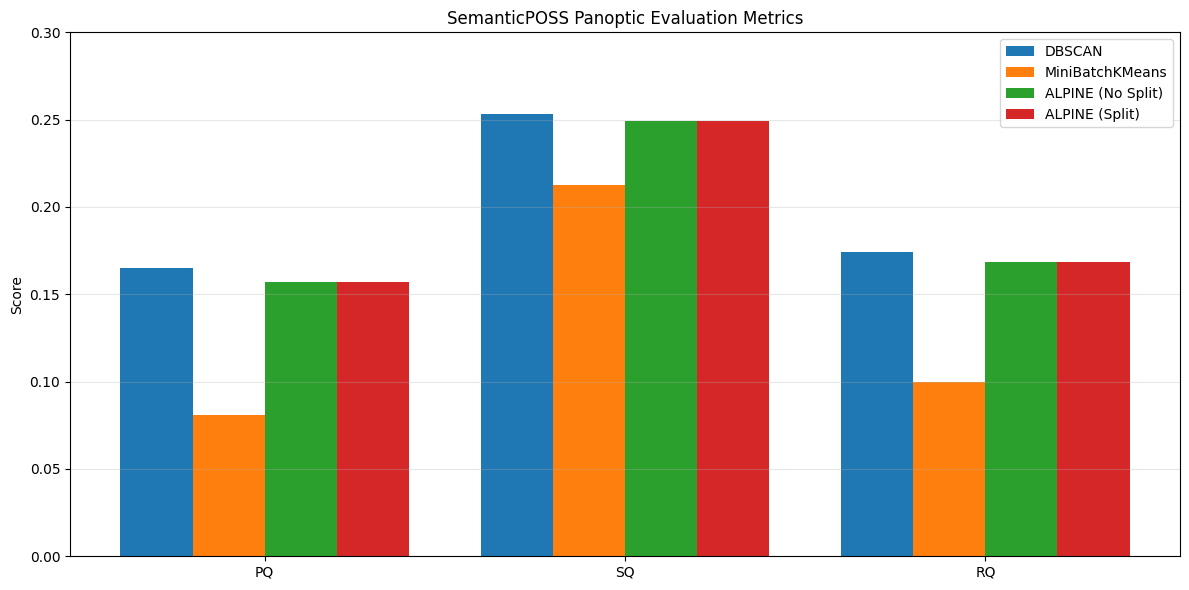

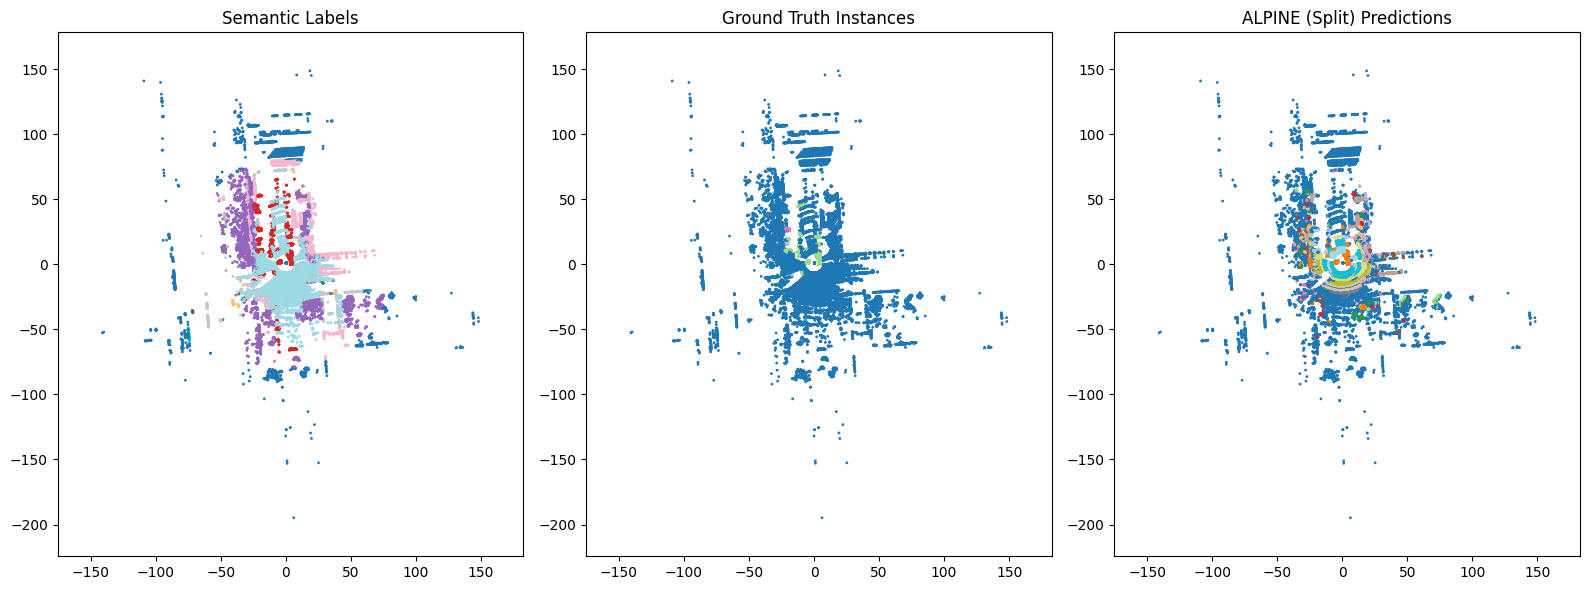

In [18]:
# Plot SemanticPOSS evaluation metrics

def plot_metrics(df_metrics, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    metrics = ['PQ', 'SQ', 'RQ']
    x = np.arange(len(metrics))
    width = 0.2
    
    for i, row in df_metrics.iterrows():
        values = [row['PQ'], row['SQ'], row['RQ']]
        ax.bar(x + i*width - 1.5*width, values, width, label=row['Model'])
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_ylim(0, 0.3)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_metrics(df_sp, 'SemanticPOSS Panoptic Evaluation Metrics')

# Visualize a sample SemanticPOSS frame
sample_frame = frame_ids[10]
pc, sem, inst_gt = load_semanticposs_frame(seq_root, sample_frame)
pred_alpine = run_alpine_sp(pc, sem, split=True)

plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
plt.scatter(pc[:, 0], pc[:, 1], c=sem, cmap='tab20', s=1)
plt.title('Semantic Labels')
plt.axis('equal')
plt.subplot(1, 3, 2)
plt.scatter(pc[:, 0], pc[:, 1], c=inst_gt, cmap='tab20', s=1)
plt.title('Ground Truth Instances')
plt.axis('equal')
plt.subplot(1, 3, 3)
plt.scatter(pc[:, 0], pc[:, 1], c=pred_alpine, cmap='tab20', s=1)
plt.title('ALPINE (Split) Predictions')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Findings and Analysis

In the experiment for the group work, alpine performed higher than the other methods but in the current experiment with different dataset, the performance of alpine is abit lower than that of DBSCAN.
- **DBSCAN** performed best on this dataset, exceeding ALPINE in PQ and RQ.
- **ALPINE** results were identical for split/no-split, indicating the splitting logic wasn't triggered by these specific class heuristics.
- **MiniBatchKMeans** is the fastest (O(n)) but has the lowest accuracy.
- **Challenge**: The main bottleneck is **Recognition Quality (RQ)**; models struggle to identify correct instance counts even when semantic labels are perfect.
- **Future Work**: **Additional tuning for the ALPINE method is needed**, specifically regarding class-specific bounding box heuristics and distance thresholds to optimize performance for the SemanticPOSS dataset characteristics.